#Implementações Computacionais de Redes Neurais.

**Disciplina:** Redes Neurais e Deep Learning  

**Aluno:** Gustavo Carvalho e Minnael Campelo

**Período:** 2026.1

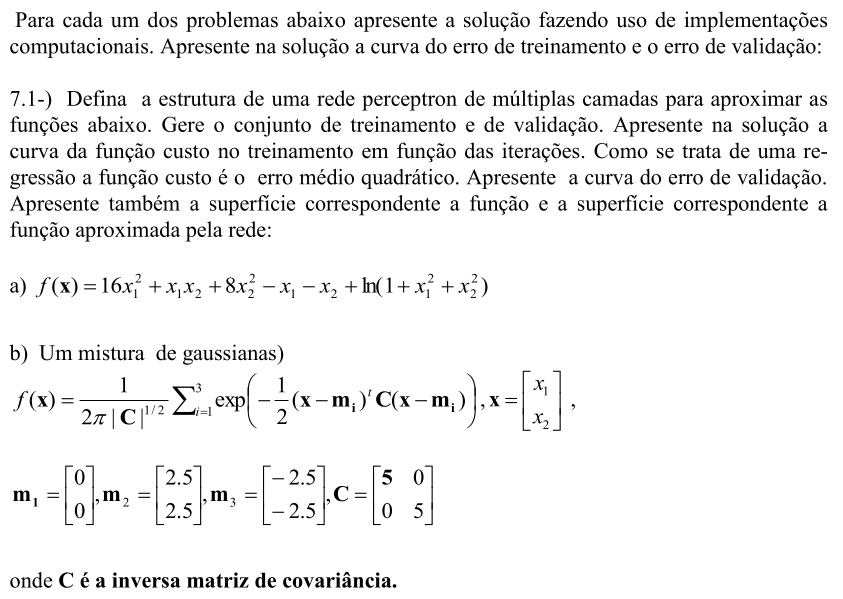

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

In [2]:
# Definição das Funções Matemáticas

def funcao_a(x1, x2):
    return 16*x1**2 + x1*x2 + 8*x2**2 - x1 - x2 + np.log(1 + x1**2 + x2**2)

def funcao_b(x1, x2):
    coef = 1 / (10 * np.pi)
    m1 = np.array([0, 0])
    m2 = np.array([2.5, 2.5])
    m3 = np.array([-2.5, -2.5])

    def gaussiana(x_vec, m):
        dist_sq = (x_vec[:, 0] - m[0])**2 + (x_vec[:, 1] - m[1])**2
        return np.exp(-2.5 * dist_sq)

    x_vec = np.column_stack((x1, x2))
    return coef * (gaussiana(x_vec, m1) + gaussiana(x_vec, m2) + gaussiana(x_vec, m3))

In [3]:
# Função pras MLPs

def build_model_A():
    """Arquitetura mais leve para a função polinomial suave."""
    model = Sequential([
        Dense(64, input_dim=2, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=0.005), loss='mse')
    return model

def build_model_B():
    """Arquitetura mais profunda e robusta para achar os picos das gaussianas."""
    model = Sequential([
        Dense(128, input_dim=2, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    # Learning rate menor para não pular os picos
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

In [4]:
# Treinamento

def treinar_e_plotar(funcao, nome_funcao, model, epochs, batch_size):
    # Domínio em [-10, 10]
    x = np.linspace(-10, 10, 100)
    y = np.linspace(-10, 10, 100)
    x1_grid, x2_grid = np.meshgrid(x, y)

    x1_flat = x1_grid.flatten()
    x2_flat = x2_grid.flatten()
    X = np.column_stack((x1_flat, x2_flat))

    Y_real = funcao(x1_flat, x2_flat)

    X_train, X_val, Y_train, Y_val = train_test_split(X, Y_real, test_size=0.2, random_state=42)

    print(f"\nTreinando a rede para a {nome_funcao}...")
    history = model.fit(X_train, Y_train,
                        validation_data=(X_val, Y_val),
                        epochs=epochs, batch_size=batch_size, verbose=0)

    # print dos Erros
    mse_treino = model.evaluate(X_train, Y_train, verbose=0)
    mse_val = model.evaluate(X_val, Y_val, verbose=0)
    print(f"-> Erro Final de Treino (MSE): {mse_treino:.6f}")
    print(f"-> Erro Final de Validação (MSE): {mse_val:.6f}")

    Y_pred = model.predict(X, verbose=0).reshape(100, 100)
    Y_real_grid = Y_real.reshape(100, 100)

    # Plot dos Resultados
    # Curva de custo
    plt.figure(figsize=(7,5))

    plt.plot(history.history['loss'], label='Erro Treino', color='blue')
    plt.plot(history.history['val_loss'], label='Erro Validação', color='orange')

    plt.title(f'Curva de Custo - {nome_funcao}')
    plt.xlabel('Iterações (Epochs)')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Superfícies
    fig = plt.figure(figsize=(12,5))

    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.plot_surface(x1_grid, x2_grid, Y_real_grid, cmap='viridis', alpha=0.8)
    ax1.set_title('Superfície Real')

    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.plot_surface(x1_grid, x2_grid, Y_pred, cmap='plasma', alpha=0.8)
    ax2.set_title('Superfície Aproximada')

    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Treinando a rede para a Função A...
-> Erro Final de Treino (MSE): 59.465717
-> Erro Final de Validação (MSE): 63.813652


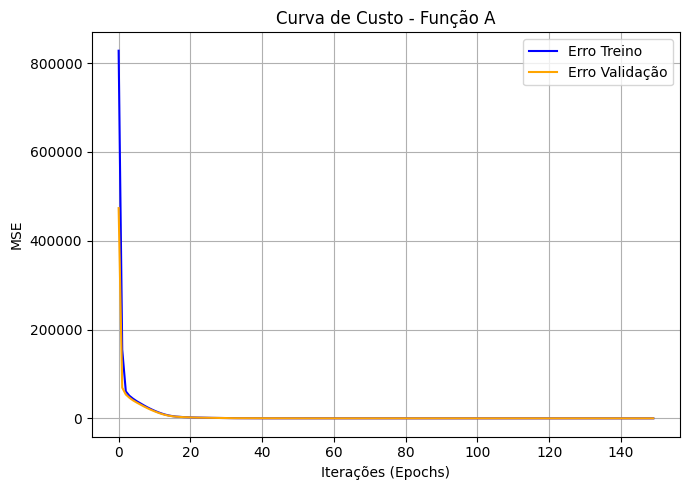

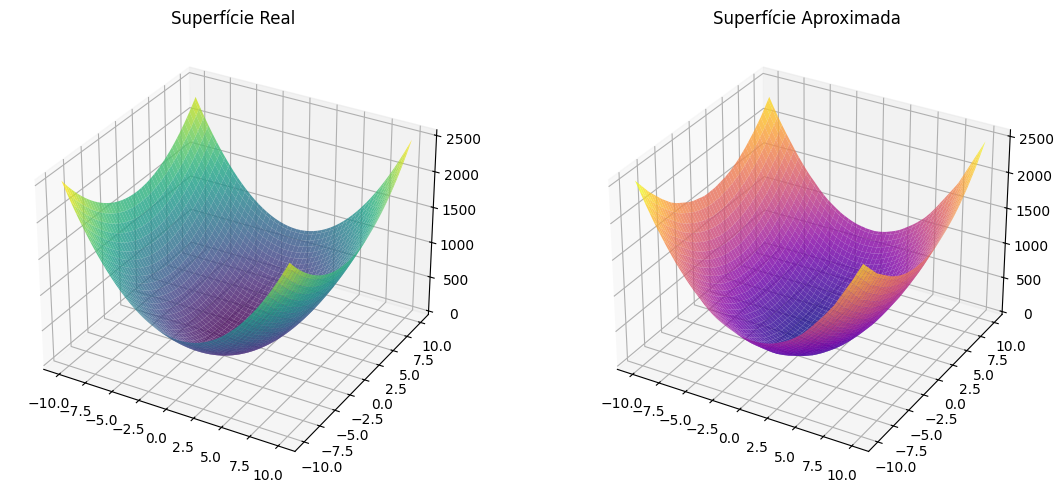

In [5]:
# Função A: Rede mais leve, menos épocas e lotes maiores
treinar_e_plotar(funcao_a, "Função A", build_model_A(), epochs=150, batch_size=128)


Treinando a rede para a Função B...
-> Erro Final de Treino (MSE): 0.000000
-> Erro Final de Validação (MSE): 0.000000


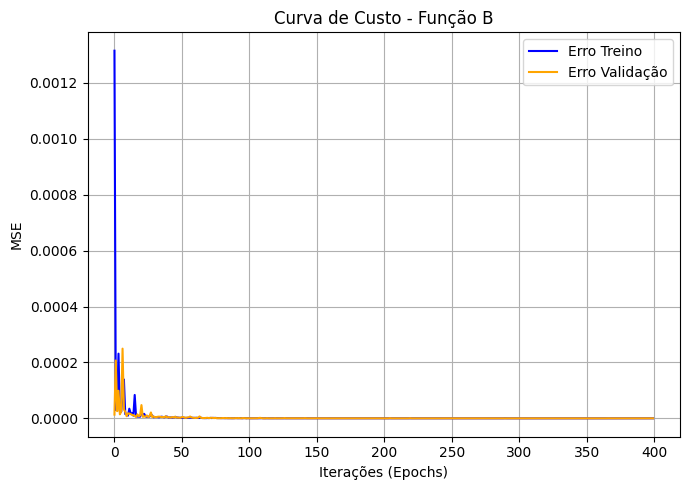

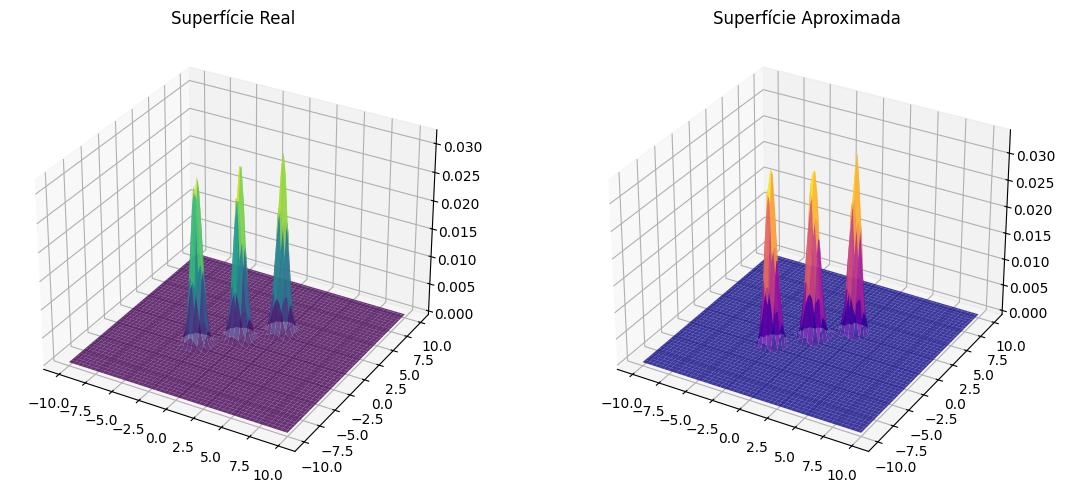

In [10]:
# Função B: Rede densa, mais épocas e lotes menores
treinar_e_plotar(funcao_b, "Função B", build_model_B(), epochs=400, batch_size=32)

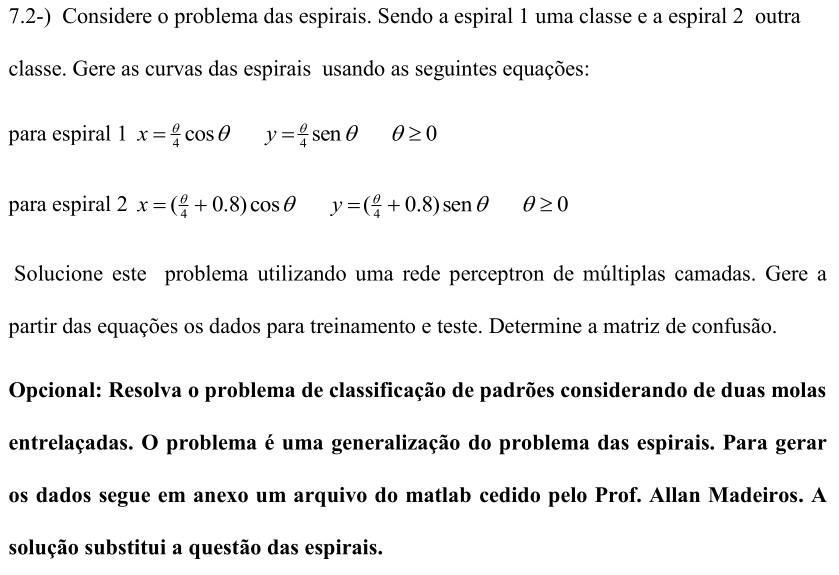

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [12]:
# Carregamento dos Dados
mat_data = loadmat('mola.mat')
D = mat_data['D'] # shape (N, 3)

X = D

N = X.shape[0]
meio = N // 2

# Primeira metade recebe classe 0 (Mola 1), segunda metade recebe classe 1 (Mola 2)
y = np.zeros(N, dtype=int)
y[meio:] = 1

# Normalização dos dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Divisão em Treinamento
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
# MLP
model = Sequential([
    Dense(64, input_dim=3, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Treinamento
print(f"Treinamento com {N} amostras")
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=300,
                    batch_size=32,
                    verbose=0)

Treinamento com 2000 amostras


In [15]:
# Avaliação e Matriz de Confusão
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).ravel()

print("=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred, target_names=['Mola 1', 'Mola 2']))

cm = confusion_matrix(y_test, y_pred)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

      Mola 1       1.00      1.00      1.00       200
      Mola 2       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



<Figure size 1600x600 with 0 Axes>

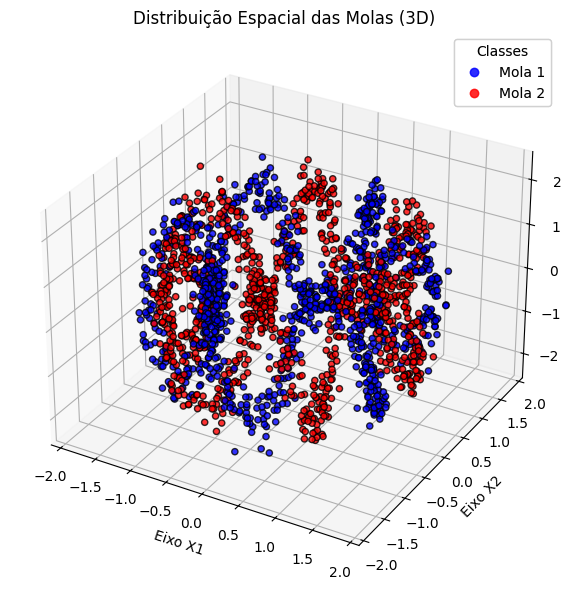

In [16]:
# Plot 3D e Matriz de Confusão

fig = plt.figure(figsize=(16, 6))

# Gráfico de Dispersão 3D
fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(111, projection='3d')

scatter = ax1.scatter(
    X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2],
    c=y, cmap='bwr', edgecolor='k', s=20, alpha=0.8
)

ax1.set_title('Distribuição Espacial das Molas (3D)')
ax1.set_xlabel('Eixo X1')
ax1.set_ylabel('Eixo X2')
ax1.set_zlabel('Eixo X3')

# legenda
legend1 = ax1.legend(*scatter.legend_elements(), title="Classes")
legend1.get_texts()[0].set_text('Mola 1')
legend1.get_texts()[1].set_text('Mola 2')
ax1.add_artist(legend1)

plt.tight_layout()
plt.show()

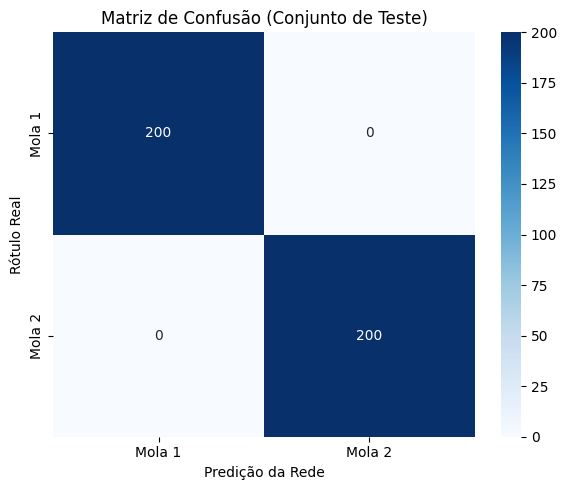

In [17]:
# Matriz de Confusão
plt.figure(figsize=(6,5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Mola 1', 'Mola 2'],
    yticklabels=['Mola 1', 'Mola 2']
)

plt.title('Matriz de Confusão (Conjunto de Teste)')
plt.xlabel('Predição da Rede')
plt.ylabel('Rótulo Real')

plt.tight_layout()
plt.show()

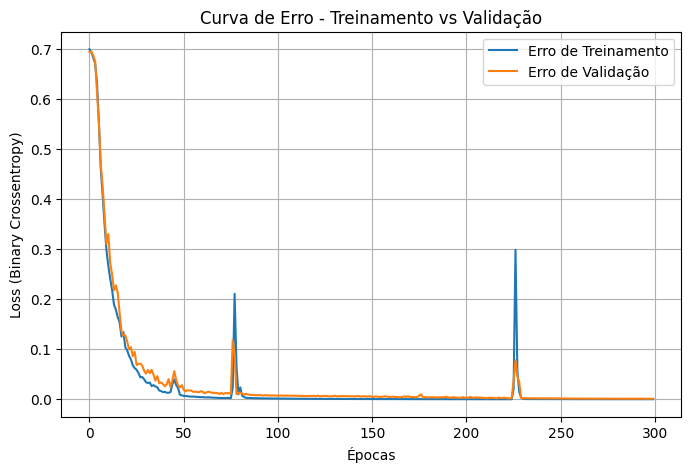

In [18]:
# Curva de erro (treino e validação)
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Erro de Treinamento')
plt.plot(history.history['val_loss'], label='Erro de Validação')

plt.xlabel('Épocas')
plt.ylabel('Loss (Binary Crossentropy)')
plt.title('Curva de Erro - Treinamento vs Validação')
plt.legend()
plt.grid(True)

plt.show()

In [19]:
#Plot dinamico só pra visualizar melhor
import plotly.graph_objects as go
from scipy.io import loadmat

# Carrega a sua matriz
D = loadmat('mola.mat')['D']
meio = D.shape[0] // 2

# Separando as molas
X_mola1 = D[:meio, :]
X_mola2 = D[meio:, :]

fig = go.Figure()

# Mola 1
fig.add_trace(go.Scatter3d(
    x=X_mola1[:, 0], y=X_mola1[:, 1], z=X_mola1[:, 2],
    mode='markers', name='Mola 1', marker=dict(size=3, color='blue')
))

# Mola 2
fig.add_trace(go.Scatter3d(
    x=X_mola2[:, 0], y=X_mola2[:, 1], z=X_mola2[:, 2],
    mode='markers', name='Mola 2', marker=dict(size=3, color='red')
))

fig.show()

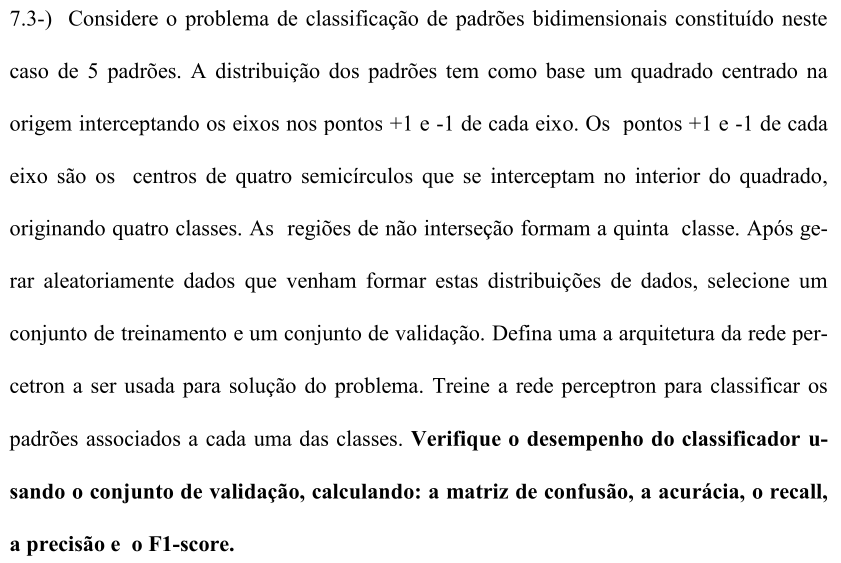

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

In [21]:
# Geração de Dados
np.random.seed(42)
N = 10000 # Gerando 10.000 pontos aleatórios
X = np.random.uniform(-1, 1, (N, 2))
Y = np.zeros(N)

In [22]:
# Classificação baseada na geometria das interseções
for i in range(N):
    x1, x2 = X[i, 0], X[i, 1]

    # Verifica pertinência aos círculos
    c1 = (x1 - 1)**2 + x2**2 <= 1
    c2 = (x1 + 1)**2 + x2**2 <= 1
    c3 = x1**2 + (x2 - 1)**2 <= 1
    c4 = x1**2 + (x2 + 1)**2 <= 1

    # Define as classes com base nas interseções
    if c1 and c3:   Y[i] = 0 # Classe 0 (Q1)
    elif c2 and c3: Y[i] = 1 # Classe 1 (Q2)
    elif c2 and c4: Y[i] = 2 # Classe 2 (Q3)
    elif c1 and c4: Y[i] = 3 # Classe 3 (Q4)
    else:           Y[i] = 4 # Classe 5 (Não interseção)

# Separação: Treinamento (80%) e Validação (20%)
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

# One-hot encoding para as variáveis alvo (exigência da função Softmax)
y_train_cat = to_categorical(y_train, num_classes=5)
y_val_cat = to_categorical(y_val, num_classes=5)

In [23]:
# MLP
model = Sequential([
    Dense(64, input_dim=2, activation='relu'),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Iniciando o treinamento da rede neural")
history = model.fit(X_train, y_train_cat,
                    validation_data=(X_val, y_val_cat),
                    epochs=50, batch_size=64, verbose=0)
print("Treinamento concluído!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Iniciando o treinamento da rede neural
Treinamento concluído!


In [24]:
# Avaliação de Desempenho

# Predições sobre o conjunto de validação
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# Acurácia, Precisão, Recall e F1-Score
print("RELATÓRIO DE CLASSIFICAÇÃO")
# O classification_report do Scikit-Learn já calcula e formata Acurácia, Precision, Recall e F1-Score
report = classification_report(y_val, y_pred, target_names=['Classe 0', 'Classe 1', 'Classe 2', 'Classe 3', 'Classe 4'])
print(report)

# Matriz de Confusão
cm = confusion_matrix(y_val, y_pred)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
RELATÓRIO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

    Classe 0       0.97      0.95      0.96       278
    Classe 1       0.99      0.95      0.97       285
    Classe 2       1.00      0.93      0.96       277
    Classe 3       1.00      0.95      0.97       274
    Classe 4       0.94      0.99      0.96       886

    accuracy                           0.96      2000
   macro avg       0.98      0.95      0.96      2000
weighted avg       0.96      0.96      0.96      2000



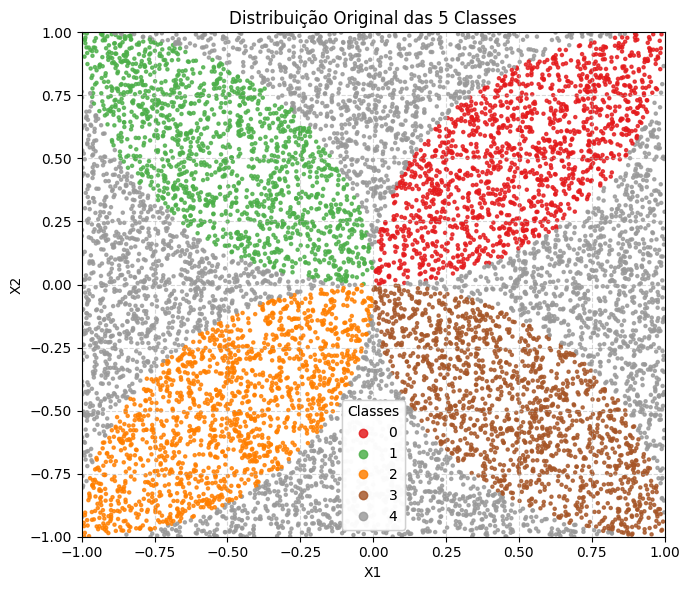

In [25]:
# Visualização dos Dados e Matriz

plt.figure(figsize=(7,6))

scatter = plt.scatter(
    X[:, 0], X[:, 1],
    c=Y, cmap='Set1', s=5, alpha=0.8
)

plt.title('Distribuição Original das 5 Classes')
plt.xlim([-1, 1])
plt.ylim([-1, 1])
plt.xlabel('X1')
plt.ylabel('X2')

# legenda
legend1 = plt.legend(*scatter.legend_elements(), title="Classes")
plt.gca().add_artist(legend1)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

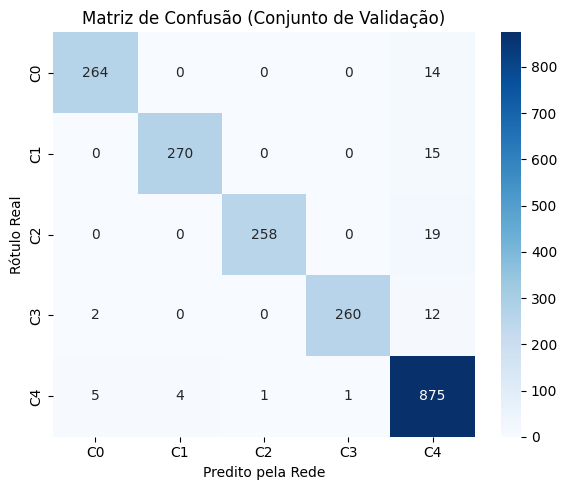

In [26]:
# Matriz de Confusão
plt.figure(figsize=(6,5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['C0', 'C1', 'C2', 'C3', 'C4'],
    yticklabels=['C0', 'C1', 'C2', 'C3', 'C4']
)

plt.title('Matriz de Confusão (Conjunto de Validação)')
plt.xlabel('Predito pela Rede')
plt.ylabel('Rótulo Real')

plt.tight_layout()
plt.show()

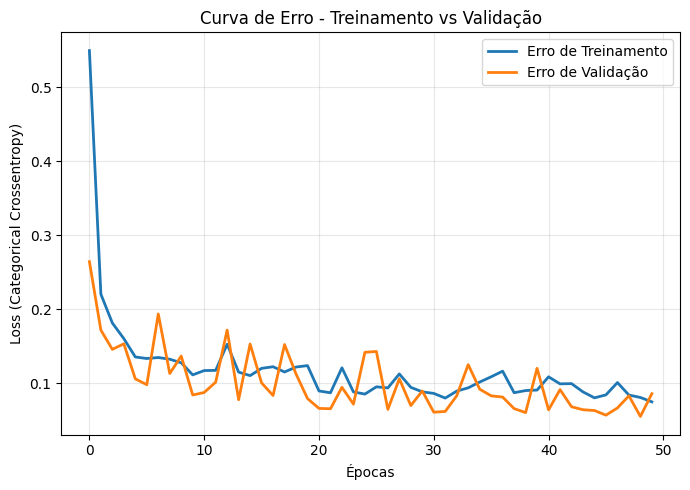

In [27]:
# Curva de erro (treino e validação)
plt.figure(figsize=(7,5))

plt.plot(history.history['loss'], label='Erro de Treinamento', linewidth=2)
plt.plot(history.history['val_loss'], label='Erro de Validação', linewidth=2)

plt.xlabel('Épocas')
plt.ylabel('Loss (Categorical Crossentropy)')
plt.title('Curva de Erro - Treinamento vs Validação')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

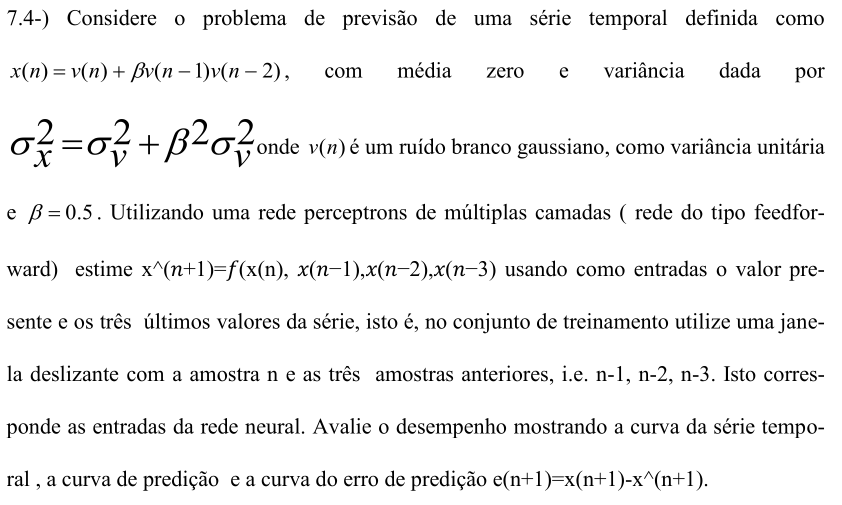

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error

In [29]:
# Geração da Série Temporal

np.random.seed(42)
N_samples = 3000
beta = 0.5

# v(n): Ruído branco gaussiano, média 0, variância 1
v = np.random.normal(0, 1, N_samples)

# x(n): Inicialização e cálculo da série
x = np.zeros(N_samples)
for n in range(2, N_samples):
    x[n] = v[n] + beta * v[n-1] * v[n-2]

In [30]:
# Construção da Janela Deslizante

# prever x(n+1) usando [x(n), x(n-1), x(n-2), x(n-3)]
X_data = []
Y_data = []

# Começamos em n=3 para termos acesso a n-3, n-2, n-1 e n.
for n in range(3, len(x) - 1):
    # Entradas: [x(n), x(n-1), x(n-2), x(n-3)]
    janela_entrada = [x[n], x[n-1], x[n-2], x[n-3]]
    # Saída: x(n+1)
    alvo = x[n+1]

    X_data.append(janela_entrada)
    Y_data.append(alvo)

X_data = np.array(X_data)
Y_data = np.array(Y_data)

In [31]:
# Divisão em Treino e Teste

# Em séries temporais, não embaralhar os dados
# para manter a ordem cronológica intacta e prever o "futuro" real.
split_ratio = 0.8
split_idx = int(len(X_data) * split_ratio)

X_train, X_test = X_data[:split_idx], X_data[split_idx:]
Y_train, Y_test = Y_data[:split_idx], Y_data[split_idx:]

In [32]:
# MLP
model = Sequential([
    Dense(32, input_dim=4, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer=Adam(learning_rate=0.005), loss='mse')

print("Treinando a MLP para previsão da série...")
history = model.fit(X_train, Y_train,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_test, Y_test),
                    verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Treinando a MLP para previsão da série...


In [33]:
# Avaliação e Cálculo do Erro e(n+1)

Y_pred = model.predict(X_test, verbose=0).flatten()

# Erro de predição: e(n+1) = x(n+1) - x_pred(n+1)
erro_predicao = Y_test - Y_pred
mse_teste = mean_squared_error(Y_test, Y_pred)

print(f"-> Limite Teórico Mínimo do MSE (Variância do Ruído v): 1.0000")
print(f"-> Erro (MSE) alcançado pela Rede Neural no Teste: {mse_teste:.4f}")

-> Limite Teórico Mínimo do MSE (Variância do Ruído v): 1.0000
-> Erro (MSE) alcançado pela Rede Neural no Teste: 1.0798


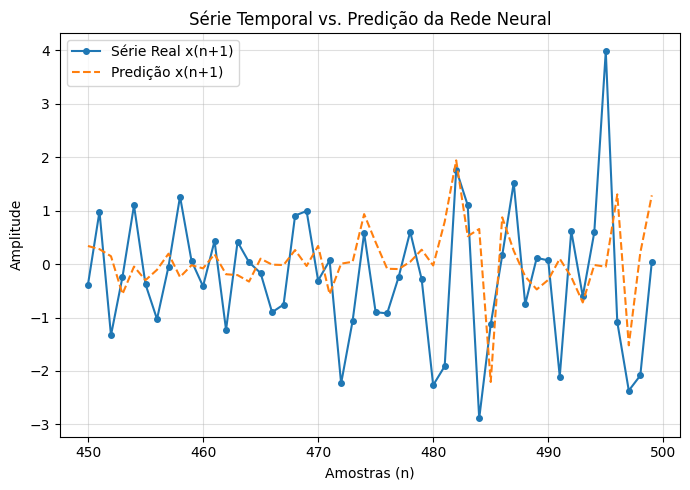

In [38]:
# Plotagem dos Resultados

plt.figure(figsize=(7,5))

zoom_inicio = 450
zoom_fim = 500
tempo = np.arange(zoom_inicio, zoom_fim)

plt.plot(tempo, Y_test[zoom_inicio:zoom_fim],
         label='Série Real x(n+1)', marker='o', markersize=4)

plt.plot(tempo, Y_pred[zoom_inicio:zoom_fim],
         label='Predição x(n+1)', linestyle='--')

plt.title('Série Temporal vs. Predição da Rede Neural')
plt.xlabel('Amostras (n)')
plt.ylabel('Amplitude')

plt.legend()
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

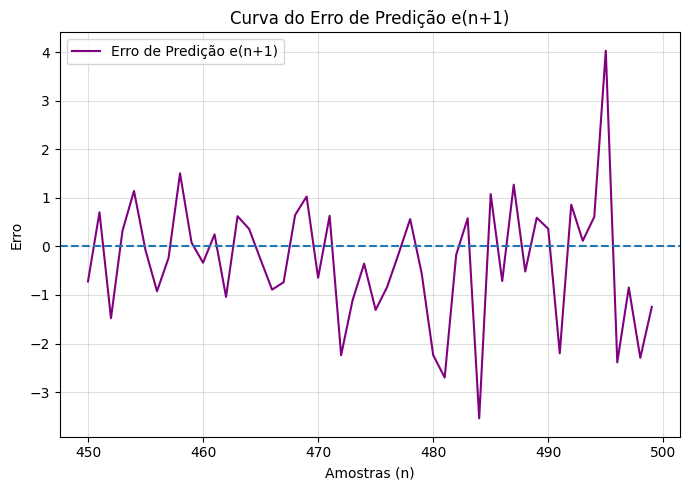

In [39]:
plt.figure(figsize=(7,5))

plt.plot(tempo, erro_predicao[zoom_inicio:zoom_fim],
         label='Erro de Predição e(n+1)', color='purple')

plt.axhline(0, linestyle='--')

plt.title('Curva do Erro de Predição e(n+1)')
plt.xlabel('Amostras (n)')
plt.ylabel('Erro')

plt.legend()
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

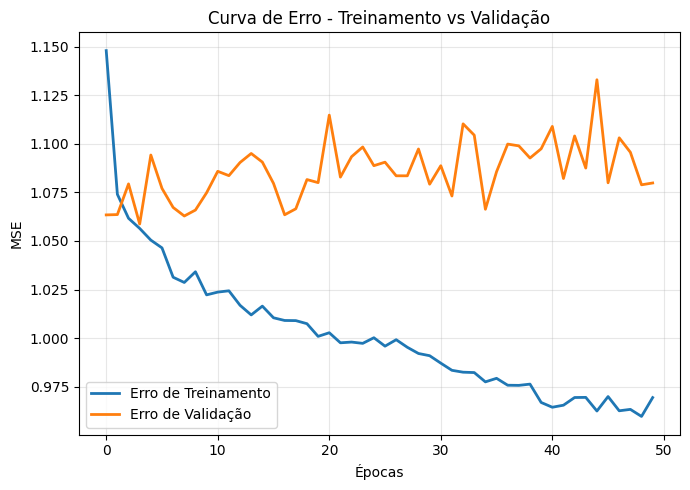

In [40]:
# Curva de erro (treino e validação)
plt.figure(figsize=(7,5))

plt.plot(history.history['loss'], label='Erro de Treinamento', linewidth=2)
plt.plot(history.history['val_loss'], label='Erro de Validação', linewidth=2)

plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.title('Curva de Erro - Treinamento vs Validação')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()